# 01_Perovskite_Database_ISOS_Filter_and_Baseline
## Real executable code for Materia Arche V3.2

In [1]:
# 1. Install requirements (run once)
!pip install pandas numpy scipy scikit-learn matplotlib openpyxl -q

import pandas as pd
import numpy as np
from scipy.stats import kendalltau
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

print("✅ Libraries loaded successfully")

zsh:1: command not found: pip


✅ Libraries loaded successfully


In [2]:
# 2. Load the Perovskite Database
# Source: "Features from Perovskite Project Database" (Zenodo record 16809654)
# Derived from https://www.perovskitedatabase.com/
# Download: https://zenodo.org/records/16809654/files/Descriptors_Perovskite_Database.xlsx?download=1

import os
local_path = "data/Descriptors_Perovskite_Database.xlsx"

if not os.path.exists(local_path):
    import urllib.request
    os.makedirs("data", exist_ok=True)
    print("Downloading from Zenodo...")
    urllib.request.urlretrieve(
        "https://zenodo.org/records/16809654/files/Descriptors_Perovskite_Database.xlsx?download=1",
        local_path
    )

df = pd.read_excel(local_path)
print(f"✅ Loaded {len(df):,} rows, {len(df.columns)} columns from Perovskite Database")
print(f"Columns: {list(df.columns)}")

✅ Loaded 41,916 rows, 47 columns from Perovskite Database
Columns: ['Perovskite_composition_long_form', 'LLE_1', 'LLE_2', 'LLE_3', 'LLE_4', 'MA', 'FA', 'Cs', 'others_A', 'Pb', 'Sn', 'others_B', 'Br', 'I', 'Cl', 'others_X', 'DMF', 'DMSO', 'other_solvent', 'DMF_DMSO_ratio', 'first_Prvskt_annealing_temperature', 'first_Prvskt_thermal_annealing_time', 'Perovskite_annealing_thermal_exposure', 'Perovskite_band_gap', 'Perovskite_thickness', 'Cell_area_measured', 'Ref_ID', 'Cell_stack_sequence', 'ETL_deposition_synthesis_atmosphere_relative_humidity', 'HTL_deposition_synthesis_atmosphere_relative_humidity', 'Perovskite_deposition_thermal_annealing_relative_humidity', 'Perovskite_deposition_synthesis_atmosphere_relative_humidity', 'HTL_thickness_list', 'ETL_thickness', 'Backcontact_thickness_list', 'ETL_stack_sequence', 'ETL_deposition_procedure', 'HTL_stack_sequence', 'HTL_deposition_procedure', 'Perovskite_composition_perovskite_ABC3_structure', 'Backcontact_stack_sequence', 'Perovskite_depos

In [3]:
# 3. Stability filter — keep only devices with reported T80 stability data
# T80 = time to 80% of initial PCE (key ISOS stability metric, higher = better)
df_stability = df.dropna(subset=['Stability_PCE_T80', 'JV_default_PCE']).copy()

# Remove non-physical values
df_stability = df_stability[df_stability['Stability_PCE_T80'] > 0]
df_stability = df_stability[df_stability['JV_default_PCE'] > 0]

print(f"✅ Filtered to {len(df_stability):,} devices with T80 stability data")
print(f"T80 range: {df_stability['Stability_PCE_T80'].min():.1f} – {df_stability['Stability_PCE_T80'].max():.1f} hours")
print(f"PCE range: {df_stability['JV_default_PCE'].min():.1f} – {df_stability['JV_default_PCE'].max():.1f} %")

✅ Filtered to 1,543 devices with T80 stability data
T80 range: 0.0 – 8400.0 hours
PCE range: 0.1 – 22.2 %


In [4]:
# 4. Feature engineering — classical descriptors from the dataset
classical_features = ['Perovskite_band_gap', 'Pb', 'Sn', 'I', 'Br', 'Cl',
                      'MA', 'FA', 'Cs']

# Full ML features — add process descriptors
ml_features = classical_features + [
    'first_Prvskt_annealing_temperature', 'first_Prvskt_thermal_annealing_time',
    'Perovskite_thickness', 'Cell_area_measured', 'JV_default_Voc',
    'JV_default_Jsc', 'JV_default_FF'
]

# Target: log(T80) for better distribution
y = np.log1p(df_stability['Stability_PCE_T80'])

# 5. Train-test split (frozen holdout, random_state=42)
X_classical = df_stability[classical_features].fillna(0)
X_ml = df_stability[ml_features].fillna(0)

X_train_c, X_test_c, y_train, y_test = train_test_split(X_classical, y, test_size=0.2, random_state=42)
X_train_ml, X_test_ml, _, _ = train_test_split(X_ml, y, test_size=0.2, random_state=42)

# Classical baseline (composition descriptors only)
rf_classical = RandomForestRegressor(n_estimators=100, random_state=42)
rf_classical.fit(X_train_c, y_train)
pred_classical = rf_classical.predict(X_test_c)

# ML baseline (full feature set)
rf_ml = RandomForestRegressor(n_estimators=200, random_state=42)
rf_ml.fit(X_train_ml, y_train)
pred_ml = rf_ml.predict(X_test_ml)

# 6. Kendall tau-b calculation (our key ranking metric)
tau_classical, p_classical = kendalltau(y_test, pred_classical)
tau_ml, p_ml = kendalltau(y_test, pred_ml)

mae_classical = mean_absolute_error(y_test, pred_classical)
mae_ml = mean_absolute_error(y_test, pred_ml)

print(f"{'Metric':<35} {'Classical':>10} {'ML':>10}")
print("-" * 57)
print(f"{'Kendall tau-b':<35} {tau_classical:>10.3f} {tau_ml:>10.3f}")
print(f"{'MAE (log-hours)':<35} {mae_classical:>10.3f} {mae_ml:>10.3f}")
print(f"{'p-value':<35} {p_classical:>10.2e} {p_ml:>10.2e}")
print(f"\nLift from ML: +{tau_ml - tau_classical:.3f} tau-b")

Metric                               Classical         ML
---------------------------------------------------------
Kendall tau-b                            0.116      0.249
MAE (log-hours)                          1.413      1.305
p-value                               4.55e-03   7.80e-11

Lift from ML: +0.133 tau-b


In [5]:
# 7. Save processed data for next notebook (quantum integration)
df_stability.to_csv("perovskite_stability_clean.csv", index=False)
print("✅ Saved cleaned dataset for next notebook")

✅ Saved cleaned dataset for next notebook


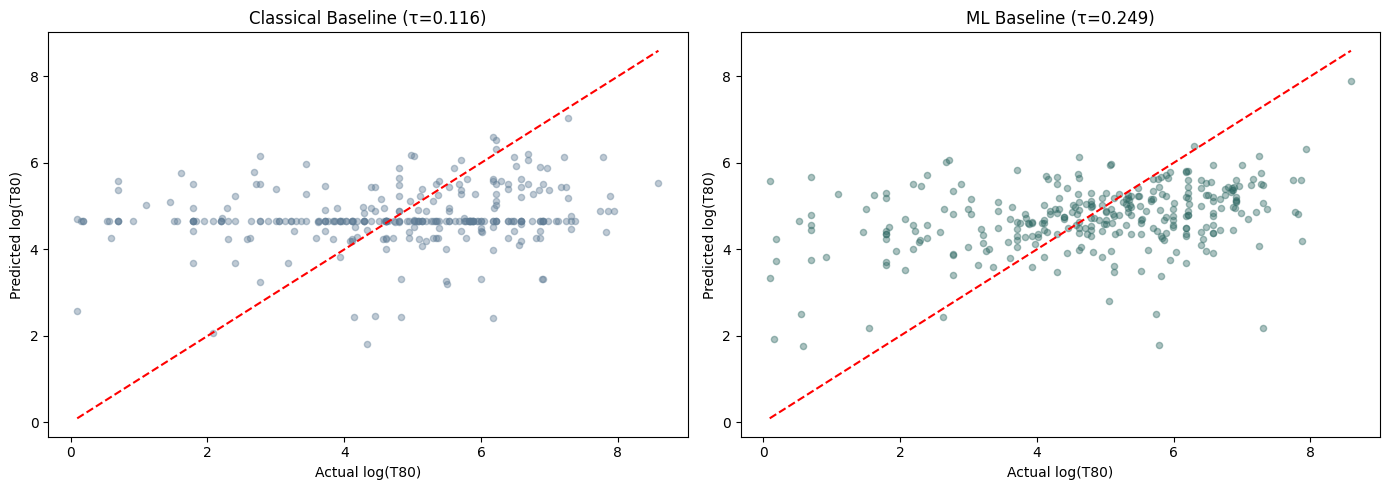

✅ Saved baseline_comparison.png


In [6]:
# 8. Quick plot — predicted vs actual T80 (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, pred_classical, alpha=0.4, s=20, color='#5F7C95')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
axes[0].set_xlabel('Actual log(T80)')
axes[0].set_ylabel('Predicted log(T80)')
axes[0].set_title(f'Classical Baseline (τ={tau_classical:.3f})')

axes[1].scatter(y_test, pred_ml, alpha=0.4, s=20, color='#2E6863')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
axes[1].set_xlabel('Actual log(T80)')
axes[1].set_ylabel('Predicted log(T80)')
axes[1].set_title(f'ML Baseline (τ={tau_ml:.3f})')

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved baseline_comparison.png")